In [1]:
import pandas as pd
import numpy as np
import json 
import time
from collections import defaultdict
from utils.train_test_split import train_test_split
from utils.neural_network import NeuralNetwork
from utils.metrics import *
from utils.smote import SMOTE
import matplotlib.pyplot as plt
import os

# Best hyperparameters
BEST_HYPERPARAMETERS = {
    'sgd': {'learning_rate': 0.01, 'momentum': 0.0},
    'adam': {'learning_rate': 0.0001},
    'adabelief': {'learning_rate': 0.0001}
}

# SMOTE ratios to test 
SMOTE_RATIOS = [None, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Architecture and training config
BEST_ARCHITECTURE = [30, 128, 64, 32, 1]
BEST_BATCH_SIZE = 64
MAX_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 15
EVALUATION_THRESHOLD = 0.5
RANDOM_STATE = 42

os.makedirs('results', exist_ok=True)

# Load datasets
df_train = pd.read_csv('dataset/creditcard_train.csv')
df_val = pd.read_csv('dataset/creditcard_val.csv')
df_test = pd.read_csv('dataset/creditcard_test.csv')

# Separate features and labels
y_train = df_train['Class']
X_train = df_train.drop('Class', axis=1)

y_val = df_val['Class']
X_val = df_val.drop('Class', axis=1)

y_test = df_test['Class']
X_test = df_test.drop('Class', axis=1)

# Store all results
all_results = defaultdict(dict)

total_experiments = len(SMOTE_RATIOS) * 3
experiment_num = 0

for smote_ratio in SMOTE_RATIOS:
    
    ratio_name = "No SMOTE" if smote_ratio is None else f"SMOTE {smote_ratio}"
    
    print("\n" + "="*100)
    print(f"  {ratio_name.upper()}")
    print("="*100)
    
    # Apply SMOTE if ratio is specified
    if smote_ratio is not None:
        print(f"\nApplying SMOTE with sampling_strategy={smote_ratio}...")
        print(f"  Before: {X_train.shape}, Fraud: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.2f}%)")
        
        smote = SMOTE(sampling_strategy=smote_ratio, random_state=RANDOM_STATE)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        
        print(f"  After:  {X_train_resampled.shape}, Fraud: {y_train_resampled.sum()}/{len(y_train_resampled)} ({y_train_resampled.mean()*100:.2f}%)")
    else:
        print(f"\n✓ Using original imbalanced data (no resampling)")
        X_train_resampled = X_train
        y_train_resampled = y_train
    
    # Train each optimizer
    for optimizer in ['sgd', 'adam', 'adabelief']:
        experiment_num += 1
        
        print(f"\n[{experiment_num}/{total_experiments}] Training {optimizer.upper()}...")
        print(f"  Hyperparameters: {BEST_HYPERPARAMETERS[optimizer]}")
        
        start_time = time.time()
        
        nn = NeuralNetwork(
            layers=BEST_ARCHITECTURE,
            activation='relu',
            output_activation='sigmoid',
            random_state=RANDOM_STATE,
            momentum=BEST_HYPERPARAMETERS['sgd']['momentum']
        )
        
        fit_kwargs = dict(
            X_val=X_val, y_val=y_val,
            epochs=MAX_EPOCHS,
            batch_size=BEST_BATCH_SIZE,
            learning_rate=BEST_HYPERPARAMETERS[optimizer]['learning_rate'],
            optimizer=optimizer,
            verbose=0,
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )

        nn.fit(X_train_resampled, y_train_resampled, **fit_kwargs)
        
        training_time = time.time() - start_time
        epochs_trained = len(nn.history['loss'])
        
        # Evaluate on test set
        y_test_pred_proba = nn.predict_proba(X_test).ravel()
        y_test_pred = (y_test_pred_proba >= EVALUATION_THRESHOLD).astype(int)

        cm = confusion_matrix(y_test, y_test_pred)
        tn, fp, fn, tp = cm.ravel()
        

        all_results[ratio_name][optimizer] = {
            'pr_auc': float(average_precision_score(y_test, y_test_pred_proba)),
            'roc_auc': float(roc_auc_score(y_test, y_test_pred_proba)),
            'f1': float(f1_score(y_test, y_test_pred, zero_division=0)),
            'precision': float(precision_score(y_test, y_test_pred, zero_division=0)),
            'recall': float(recall_score(y_test, y_test_pred, zero_division=0)),
            'accuracy': float(accuracy_score(y_test, y_test_pred)),
            'tp': int(tp), 'fp': int(fp),
            'fn': int(fn), 'tn': int(tn),
            'epochs': epochs_trained,
            'time': training_time
        }
        
        print(f"  ✓ Completed in {training_time:.1f}s ({epochs_trained} epochs)")
        print(f"    PR-AUC: {all_results[ratio_name][optimizer]['pr_auc']:.4f} | "
              f"ROC-AUC: {all_results[ratio_name][optimizer]['roc_auc']:.4f} | "
              f"F1: {all_results[ratio_name][optimizer]['f1']:.4f}")
        print(f"    TP: {tp}  FP: {fp}  FN: {fn}  TN: {tn}")

results_data = []
for ratio_name in ["No SMOTE"] + [f"SMOTE {r}" for r in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]:
    if ratio_name in all_results:
        for optimizer in ['sgd', 'adam', 'adabelief']:
            if optimizer in all_results[ratio_name]:
                r = all_results[ratio_name][optimizer]
                results_data.append({
                    'SMOTE Ratio': ratio_name,
                    'Optimizer': optimizer.upper(),
                    'PR-AUC': round(r['pr_auc'], 4),
                    'ROC-AUC': round(r['roc_auc'], 4),
                    'F1-Score': round(r['f1'], 4),
                    'Precision': round(r['precision'], 4),
                    'Recall': round(r['recall'], 4),
                    'Accuracy': round(r['accuracy'], 4),
                    'TP': r['tp'], 'FP': r['fp'],
                    'FN': r['fn'], 'TN': r['tn'],
                    'Epochs': r['epochs'],
                    'Time (s)': round(r['time'], 1)
                })

results_df = pd.DataFrame(results_data)
results_df.to_csv('results/rev_smote_results_all.csv', index=False)
print(f"\n✓ Saved: results/smote_results_all.csv")
print(f"\n{results_df.to_string(index=False)}")


  NO SMOTE

✓ Using original imbalanced data (no resampling)

[1/33] Training SGD...
  Hyperparameters: {'learning_rate': 0.01, 'momentum': 0.0}
  ✓ Completed in 63.9s (80 epochs)
    PR-AUC: 0.8086 | ROC-AUC: 0.9558 | F1: 0.8154
    TP: 53  FP: 7  FN: 17  TN: 42480

[2/33] Training ADAM...
  Hyperparameters: {'learning_rate': 0.0001}
  ✓ Completed in 25.6s (25 epochs)
    PR-AUC: 0.7980 | ROC-AUC: 0.9655 | F1: 0.7970
    TP: 53  FP: 10  FN: 17  TN: 42477

[3/33] Training ADABELIEF...
  Hyperparameters: {'learning_rate': 0.0001}
  ✓ Completed in 30.4s (27 epochs)
    PR-AUC: 0.8083 | ROC-AUC: 0.9624 | F1: 0.8029
    TP: 55  FP: 12  FN: 15  TN: 42475

  SMOTE 0.1

Applying SMOTE with sampling_strategy=0.1...
  Before: (198610, 30), Fraud: 332/198610 (0.17%)
Original class distribution:
  Class 0: 198278 samples (99.83%)
  Class 1: 332 samples (0.17%)
Generating 19495 synthetic samples for class 1

Resampled class distribution:
  Class 0: 198278 samples (90.91%)
  Class 1: 19827 samples

✓ Visualization saved to: smote_ratio_impact.png


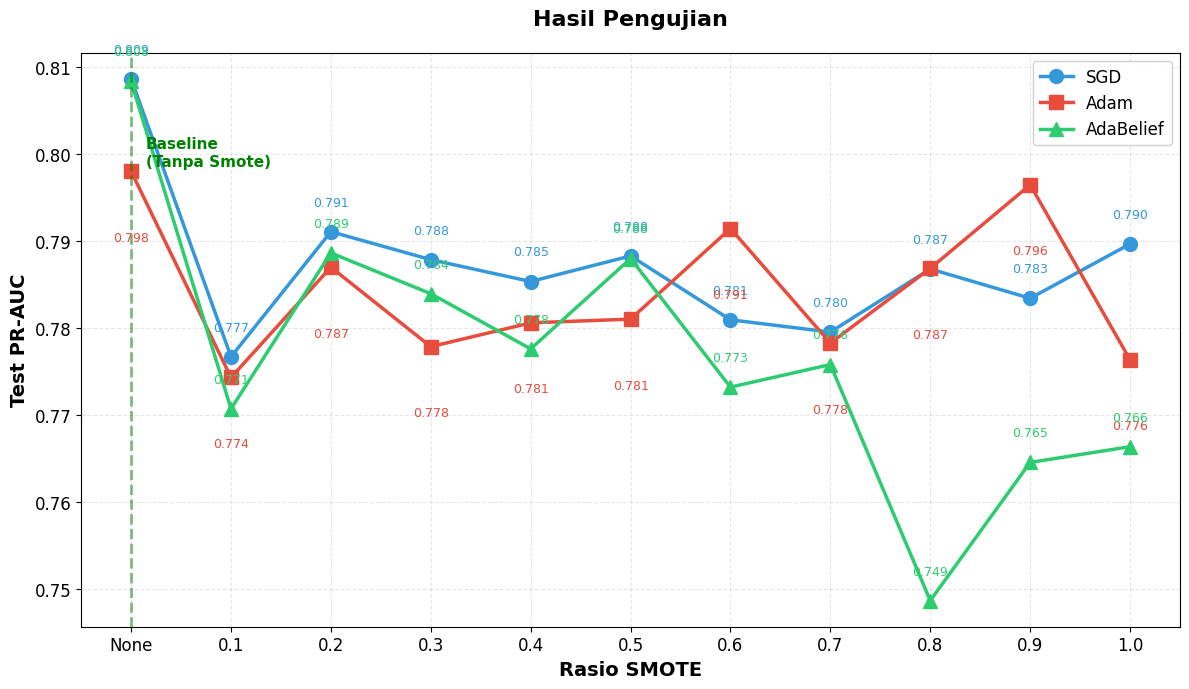


STEP 6: STATISTICAL ANALYSIS

Performance degradation from baseline (No SMOTE):
--------------------------------------------------------------------------------

SMOTE 0.1:
  SGD       : 0.8086 → 0.7767 (-0.0320, -3.95%)
  ADAM      : 0.7980 → 0.7743 (-0.0237, -2.97%)
  ADABELIEF : 0.8083 → 0.7707 (-0.0377, -4.66%)

SMOTE 0.2:
  SGD       : 0.8086 → 0.7911 (-0.0176, -2.17%)
  ADAM      : 0.7980 → 0.7870 (-0.0110, -1.38%)
  ADABELIEF : 0.8083 → 0.7886 (-0.0197, -2.44%)

SMOTE 0.3:
  SGD       : 0.8086 → 0.7878 (-0.0208, -2.57%)
  ADAM      : 0.7980 → 0.7778 (-0.0202, -2.53%)
  ADABELIEF : 0.8083 → 0.7839 (-0.0244, -3.02%)

SMOTE 0.4:
  SGD       : 0.8086 → 0.7853 (-0.0233, -2.88%)
  ADAM      : 0.7980 → 0.7806 (-0.0174, -2.18%)
  ADABELIEF : 0.8083 → 0.7776 (-0.0308, -3.81%)

SMOTE 0.5:
  SGD       : 0.8086 → 0.7883 (-0.0204, -2.52%)
  ADAM      : 0.7980 → 0.7810 (-0.0170, -2.13%)
  ADABELIEF : 0.8083 → 0.7880 (-0.0204, -2.52%)

SMOTE 0.6:
  SGD       : 0.8086 → 0.7809 (-0.0277, -3.43%

In [2]:
# Prepare data for plotting
all_smote_labels = ['None', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
all_ratio_names = ["No SMOTE"] + [f"SMOTE {r}" for r in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]

sgd_scores = []
adam_scores = []
adabelief_scores = []
smote_labels = []

for label, ratio_name in zip(all_smote_labels, all_ratio_names):
    if ratio_name in all_results:
        smote_labels.append(label)
        sgd_scores.append(all_results[ratio_name]['sgd']['pr_auc'])
        adam_scores.append(all_results[ratio_name]['adam']['pr_auc'])
        adabelief_scores.append(all_results[ratio_name]['adabelief']['pr_auc'])

smote_x = list(range(len(smote_labels)))

# Create plot
plt.figure(figsize=(12, 7))
plt.plot(smote_x, sgd_scores, 'o-', linewidth=2.5, markersize=10, label='SGD', color='#3498db')
plt.plot(smote_x, adam_scores, 's-', linewidth=2.5, markersize=10, label='Adam', color='#e74c3c')
plt.plot(smote_x, adabelief_scores, '^-', linewidth=2.5, markersize=10, label='AdaBelief', color='#2ecc71')

# Formatting
plt.xlabel('Rasio SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Test PR-AUC', fontsize=14, fontweight='bold')
plt.title('Hasil Pengujian', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(smote_x, smote_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='best', framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')

# Add value labels on points
for i, (x, sgd, adam, ada) in enumerate(zip(smote_x, sgd_scores, adam_scores, adabelief_scores)):
    plt.text(x, sgd + 0.003, f'{sgd:.3f}', ha='center', fontsize=9, color='#3498db')
    plt.text(x, adam - 0.008, f'{adam:.3f}', ha='center', fontsize=9, color='#e74c3c')
    plt.text(x, ada + 0.003, f'{ada:.3f}', ha='center', fontsize=9, color='#2ecc71')

# Highlight baseline
plt.axvline(x=0, color='green', linestyle='--', alpha=0.5, linewidth=2)
plt.text(0.15, max(sgd_scores + adam_scores + adabelief_scores) - 0.01, 
         'Baseline\n(Tanpa Smote)', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('rev_smote_ratio_impact_all.png', dpi=300, bbox_inches='tight')
print(f"✓ Visualization saved to: smote_ratio_impact.png")
plt.show()

# ============================================================================
# STEP 6: Statistical Summary
# ============================================================================

print("\n" + "="*100)
print("STEP 6: STATISTICAL ANALYSIS")
print("="*100)

print("\nPerformance degradation from baseline (No SMOTE):")
print("-" * 80)

baseline_results = all_results["No SMOTE"]

for ratio_name in [f"SMOTE {r}" for r in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]:
    if ratio_name in all_results:
        print(f"\n{ratio_name}:")
        for optimizer in ['sgd', 'adam', 'adabelief']:
            baseline_auc = baseline_results[optimizer]['pr_auc']
            smote_auc = all_results[ratio_name][optimizer]['pr_auc']
            diff = smote_auc - baseline_auc
            pct_change = (diff / baseline_auc) * 100
            
            print(f"  {optimizer.upper():10s}: {baseline_auc:.4f} → {smote_auc:.4f} "
                  f"({diff:+.4f}, {pct_change:+.2f}%)")

print("\n" + "="*100)
print("ANALYSIS COMPLETE!")
print("="*100)
print("\nKey Findings:")
print("1. Check if ALL SMOTE ratios perform worse than baseline")
print("2. Identify which optimizer is most robust to SMOTE noise")
print("3. Determine optimal strategy for your thesis")
print("="*100)

# Save all results to JSON
with open('rev_smote_sensitivity_complete_results_all.json', 'w') as f:
    # Convert to JSON-serializable format
    json_results = {}
    for ratio, optimizers in all_results.items():
        json_results[ratio] = {}
        for opt, metrics in optimizers.items():
            json_results[ratio][opt] = {k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
                                        for k, v in metrics.items()}
    json.dump(json_results, f, indent=2)

print(f"\n✓ Complete results saved to: smote_sensitivity_complete_results_all.json")
